患者ID        int64
年龄        float64
性别            str
地区            str
就诊日期          str
疾病类型          str
诊断日期          str
疾病严重程度        str
治疗方案          str
治疗结果          str
药物名称          str
药物分类          str
用药剂量          str
用药时长          str
检查项目          str
检查结果      float64
参考范围          str
体重        float64
身高        float64
吸烟情况          str
饮酒情况          str
遗传病史          str
诊断延迟      float64
病程        float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 2705 entries, 0 to 2704
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   患者ID    2705 non-null   int64  
 1   年龄      2705 non-null   float64
 2   性别      2705 non-null   str    
 3   地区      2705 non-null   str    
 4   就诊日期    2705 non-null   str    
 5   疾病类型    2705 non-null   str    
 6   诊断日期    2705 non-null   str    
 7   疾病严重程度  2705 non-null   str    
 8   治疗方案    2704 non-null   str    
 9   治疗结果    2703 non-null   str    
 10  药物名称    2

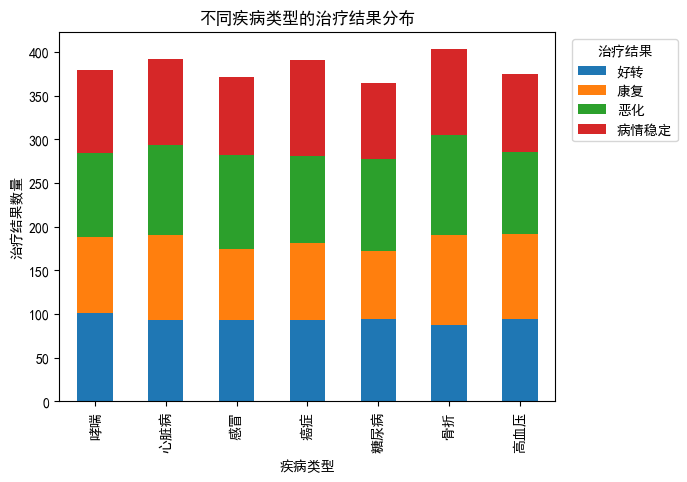

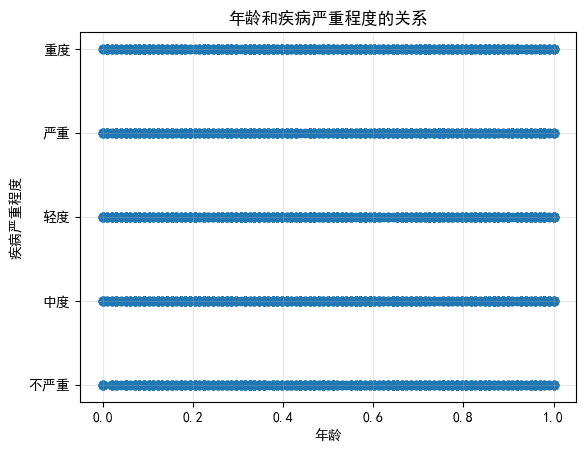

In [19]:
import pandas as pd

# 加载数据集并指定编码
data = pd.read_csv('2.1.4_cleaned_data.csv')

# 查看数据类型
print(data.dtypes)
# 查看表结构
print(data.info())
# 显示每一列的空缺值数量
print(data.isnull().sum())

# 规范日期格式
data['就诊日期'] = pd.to_datetime(data['就诊日期'])
data['诊断日期'] = pd.to_datetime(data['诊断日期'])

# 重命名列
data.rename(columns={'病人ID': '患者ID'}, inplace=True)

# 查看修改后的表结构
print(data.head())

from datetime import datetime

# 增加诊断延迟和病程
data['诊断延迟'] = (data['诊断日期'] - data['就诊日期']).dt.days

today = datetime.now().date()
data['病程'] = (pd.Timestamp(today) - data['诊断日期']).dt.days

# 删除不合理的数据
data= data[(data['诊断延迟'] >= 0) & (data['年龄'] > 0) & (data['年龄'] < 120)]

# 查看修改后的数据
print(data.describe())

# 删除重复值并记录删除的行数
initial_rows = data.shape[0]
data.drop_duplicates(inplace=True)
deleted_rows = initial_rows - data.shape[0]

print(f'删除的重复行数: {deleted_rows}')

from sklearn.preprocessing import MinMaxScaler

# 对需要归一化的列进行处理
scaler = MinMaxScaler()
columns_to_normalize = ['年龄', '体重', '身高']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

# 查看归一化后的数据
print(data.head())

import matplotlib.pyplot as plt

# 统计治疗结果分布
treatment_outcome_distribution = data.groupby('疾病类型')['治疗结果'].value_counts().unstack()

# ========== 解决中文方框乱码！这两行要放在绘图代码最前面 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘制柱状图
treatment_outcome_distribution.plot(kind='bar', stacked=True)
plt.title('不同疾病类型的治疗结果分布')
plt.xlabel('疾病类型')
plt.ylabel('治疗结果数量')
plt.legend(title="治疗结果", bbox_to_anchor=(1.02,1), loc="upper left") # 图例放外侧
plt.show()

# 绘制散点图
plt.scatter(data['年龄'], data['疾病严重程度'])
plt.title('年龄和疾病严重程度的关系')
plt.xlabel('年龄')
plt.ylabel('疾病严重程度')
plt.grid(alpha=0.3)
plt.show()

data.to_csv('2.1.4_cleaned_data1.csv')